# Lista 1

**Aluno:** [Eduardo Maciel Alexandre](mailto:ema2@ic.ufal.br)
\
**Nome da base:** "WA_Fn-UseC_-Telco-Customer-Churn.csv"

## Orientações

- Escolha apenas uma das bases disponíveis e resolva todas as 10 questões usando essa mesma base.
- Desenvolva toda a atividade em Python, no formato de entrega do Google Colab.
- Organize o notebook por questão, com códigos executáveis, saídas geradas e comentários objetivos.
- Não troque de base ao longo da atividade.
- Não faça tratamento manual linha por linha.
- Sempre que necessário, sustente suas decisões com tabelas, métricas, gráficos e resultados do código.

## Importação das bibliotecas

In [21]:
# Bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Pré-processamento e modelagem
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

# Configuração visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Carregamento da base

In [22]:
# Carregamento da base escolhida para toda a atividade
df = pd.read_csv('./data/Telco-Customer-Churn.csv')

# Visualização inicial
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Questão 1 – Diagnóstico estrutural

**Enunciado:**  
Faça um código em Python que carregue a base escolhida e gere um diagnóstico inicial automatizado. Mostre dimensões da base, tipos de dados, valores ausentes, duplicidades, cardinalidade das colunas e possíveis inconsistências de leitura. Em seguida, defina qual será o problema computacional tratado no cenário escolhido, deixando claro se a tarefa será de classificação, regressão ou segmentação. Organize essa etapa em uma função reutilizável.

### Raciocínio
A estratégia foi criar uma função única de diagnóstico para evitar análises manuais coluna a coluna. Essa função calcula automaticamente: dimensões, tipos de dados, ausências, duplicidades e cardinalidade. Além disso, inclui uma auditoria inicial de inconsistências de leitura, procurando padrões comuns em bases reais como textos com espaços extras, valores vazios em colunas textuais e colunas numéricas lidas como texto (caso clássico de `TotalCharges` no Telco).

### Desenvolvimento
Implementar uma função reutilizável `structural_diagnosis`, aplicá-la ao `df` e apresentar as tabelas-resumo + definição formal do problema computacional.

In [23]:
# Código da Questão 1
def structural_diagnosis(df: pd.DataFrame, target: str) -> dict:
    summary = {}

    # 1) Dimensões
    summary['dimensions'] = {'linhas': df.shape[0], 'colunas': df.shape[1]}

    # 2) Tipos de dados
    data_types = df.dtypes.astype(str).rename('dtype').to_frame()

    # 3) Valores ausentes
    missing_abs = df.isna().sum().rename('ausentes_abs') # Contagem absoluta de ausentes
    missing_pct = (df.isna().mean() * 100).round(2).rename('ausentes_pct') # Percentual de ausentes

    # 4) Cardinalidade
    cardinality = df.nunique(dropna=False).rename('cardinalidade')

    # 5) Quadro estrutural consolidado
    structural_table = pd.concat([data_types, missing_abs, missing_pct, cardinality], axis=1) # Concatenação das informações estruturais
    structural_table = structural_table.sort_values(by=['ausentes_abs', 'cardinalidade'], ascending=False)
    summary['structural_table'] = structural_table

    # 6) Duplicidades
    summary['duplicates_abs'] = int(df.duplicated().sum()) # Contagem absoluta de duplicatas
    summary['duplicates_pct'] = round(float(df.duplicated().mean() * 100), 2) # Percentual de duplicatas

    # 7) Inconsistências de leitura
    inconsistencies = []
    for column in df.columns:
        series = df[column]

        if pd.api.types.is_string_dtype(series):
            text_series = series.astype(str)

            # Espaços em excesso (início/fim)
            trim_diff = (text_series.fillna('') != text_series.fillna('').str.strip()).sum()
            if trim_diff > 0:
                inconsistencies.append({
                    'coluna': column,
                    'tipo_problema': 'espacos_extras',
                    'qtd_registros': int(trim_diff),
                    'detalhe': 'Valores com espaços no início/fim.'
                })

            # Vazios textuais ("", " ", etc.)
            text_empty = text_series.str.strip().eq('').sum()
            if text_empty > 0:
                inconsistencies.append({
                    'coluna': column,
                    'tipo_problema': 'vazio_textual',
                    'qtd_registros': int(text_empty),
                    'detalhe': 'Campos vazios mascarados como string.'
                })

            # Possível numérica lida como texto
            numeric_try = pd.to_numeric(text_series.str.strip(), errors='coerce')
            non_null = series.notna().sum()
            convertible = numeric_try.notna().sum()

            if non_null > 0 and (convertible / non_null) >= 0.8:
                inconsistencies.append({
                    'coluna': column,
                    'tipo_problema': 'numerica_em_texto',
                    'qtd_registros': int(convertible),
                    'detalhe': 'Coluna majoritariamente numérica armazenada como texto.'
                })

    inconsistencies_df = pd.DataFrame(inconsistencies)
    if not inconsistencies_df.empty:
        inconsistencies_df = inconsistencies_df.sort_values(by=['qtd_registros', 'coluna'], ascending=False)

    summary['inconsistencies'] = inconsistencies_df

    # 8) Definição do problema computacional
    target_classes = sorted(str(c) for c in df[target].dropna().unique())
    summary['problem'] = {
        'tipo': 'Classificação binária',
        'variavel_alvo': target,
        'classes_observadas': sorted(target_classes),
        'objetivo': 'Prever se um cliente irá cancelar (Churn = Yes) ou permanecer (Churn = No).'
    }

    return summary


q1_results = structural_diagnosis(df, target='Churn')

print('Dimensões da base:', q1_results['dimensions'])
print(f"Duplicatas: {q1_results['duplicates_abs']} ({q1_results['duplicates_pct']}%)")
print('\nDefinição do problema computacional:')
for key, value in q1_results['problem'].items():
    print(f'- {key}: {value}')

print('\nTop 10 colunas no diagnóstico estrutural:')
display(q1_results['structural_table'].head(10))

print('Possíveis inconsistências de leitura:')
if q1_results['inconsistencies'].empty:
    print('Nenhuma inconsistência detectada pelas regras automáticas.')
else:
    display(q1_results['inconsistencies'])

Dimensões da base: {'linhas': 7043, 'colunas': 21}
Duplicatas: 0 (0.0%)

Definição do problema computacional:
- tipo: Classificação binária
- variavel_alvo: Churn
- classes_observadas: ['No', 'Yes']
- objetivo: Prever se um cliente irá cancelar (Churn = Yes) ou permanecer (Churn = No).

Top 10 colunas no diagnóstico estrutural:


,dtype,ausentes_abs,ausentes_pct,cardinalidade
customerID,str,0,0.0,7043
TotalCharges,str,0,0.0,6531
MonthlyCharges,float64,0,0.0,1585
tenure,int64,0,0.0,73
PaymentMethod,str,0,0.0,4
MultipleLines,str,0,0.0,3
InternetService,str,0,0.0,3
OnlineSecurity,str,0,0.0,3
OnlineBackup,str,0,0.0,3
DeviceProtection,str,0,0.0,3


Possíveis inconsistências de leitura:


,coluna,tipo_problema,qtd_registros,detalhe
2,TotalCharges,numerica_em_texto,7032,Coluna majoritariamente numérica armazenada co...
0,TotalCharges,espacos_extras,11,Valores com espaços no início/fim.
1,TotalCharges,vazio_textual,11,Campos vazios mascarados como string.


### Conclusão da Questão 1
O diagnóstico estrutural confirmou que a base possui **7043 linhas e 21 colunas**, sem registros duplicados, e que o problema central será de **classificação binária** com alvo `Churn` (`Yes`/`No`). A inspeção automática também identificou uma inconsistência crítica na coluna `TotalCharges`: ela está armazenada como texto, com **11 registros vazios/espaços**, o que exige tratamento de tipagem e ausências nas próximas etapas. Assim, a base está adequada ao objetivo didático, mas depende de limpeza reproduzível antes da modelagem.

## Questão 2 – Auditoria de qualidade

**Enunciado:**  
Faça um código em Python para auditar a qualidade dos dados. Identifique valores implausíveis, colunas com tipos inadequados, categorias raras, padrões suspeitos de preenchimento, possíveis outliers e inconsistências importantes para o cenário escolhido. Se houver datas, verifique coerência temporal. Se houver valores monetários, verifique compatibilidade entre grandezas. Ao final, apresente um resumo dos principais problemas encontrados.

### Raciocínio
A auditoria será feita com uma função reutilizável `data_quality_audit`, aplicada à base Telco sem tratamento manual linha a linha. A estratégia cobre: (1) validação de tipagem com foco em colunas numéricas lidas como texto, (2) ausências explícitas e ausências mascaradas por espaços, (3) valores implausíveis para variáveis numéricas do cenário, (4) categorias raras em variáveis categóricas, (5) outliers por IQR e (6) compatibilidade monetária entre `tenure`, `MonthlyCharges` e `TotalCharges`. Como a base não possui coluna de data, a checagem temporal será registrada como não aplicável.

### Desenvolvimento
Implementar abaixo a função de auditoria, gerar tabelas-resumo e gráficos objetivos para sustentar os principais problemas encontrados.

Resumo da auditoria de qualidade:
- tipagem_inadequada_cols: 1
- colunas_com_ausencia_explicita: 0
- colunas_com_vazio_textual: 1
- colunas_id_like: 1
- regras_implausiveis_violadas: 0
- colunas_com_categorias_raras: 0
- colunas_numericas_com_outliers: 0
- suspeitos_monetarios_abs: 365

Tabela de ausências (top 10):


,coluna,ausentes_abs,ausentes_pct
20,Churn,0,0.0
15,Contract,0,0.0
4,Dependents,0,0.0
11,DeviceProtection,0,0.0
8,InternetService,0,0.0
18,MonthlyCharges,0,0.0
7,MultipleLines,0,0.0
10,OnlineBackup,0,0.0
9,OnlineSecurity,0,0.0
16,PaperlessBilling,0,0.0


Vazios textuais detectados:


,coluna,vazios_textuais,pct_vazios_textuais
0,TotalCharges,11,0.16



Possíveis problemas de tipagem:


...


Colunas com perfil de identificador (alta cardinalidade):


,coluna,cardinalidade,razao_unicidade_pct
0,customerID,7043,100.0



Valores implausíveis:
Nenhum valor implausível encontrado com as regras definidas.

Categorias raras (frequência < 1%):
Nenhuma coluna de atributos categóricos com categorias raras abaixo do limiar.

Outliers por IQR:


,coluna,q1,q3,limite_inferior,limite_superior,outliers_abs,outliers_pct
0,tenure,9.00,55.0000,-60.0000,124.0000,0,0.0
1,MonthlyCharges,35.50,89.8500,-46.0250,171.3750,0,0.0
2,TotalCharges,401.45,3794.7375,-4688.4813,8884.6688,0,0.0



Checagem monetária (TotalCharges vs MonthlyCharges * tenure):
- registros_avaliados: 7032
- limite_erro_absoluto_iqr: 145.0937
- suspeitos_abs: 365
- suspeitos_pct: 5.18
- mediana_erro_absoluto: 28.65

Padrão de preenchimento suspeito (TotalCharges):
- totalcharges_vazios_abs: 11
- totalcharges_vazios_com_tenure_zero_abs: 11
- totalcharges_vazios_com_tenure_zero_pct: 100.0


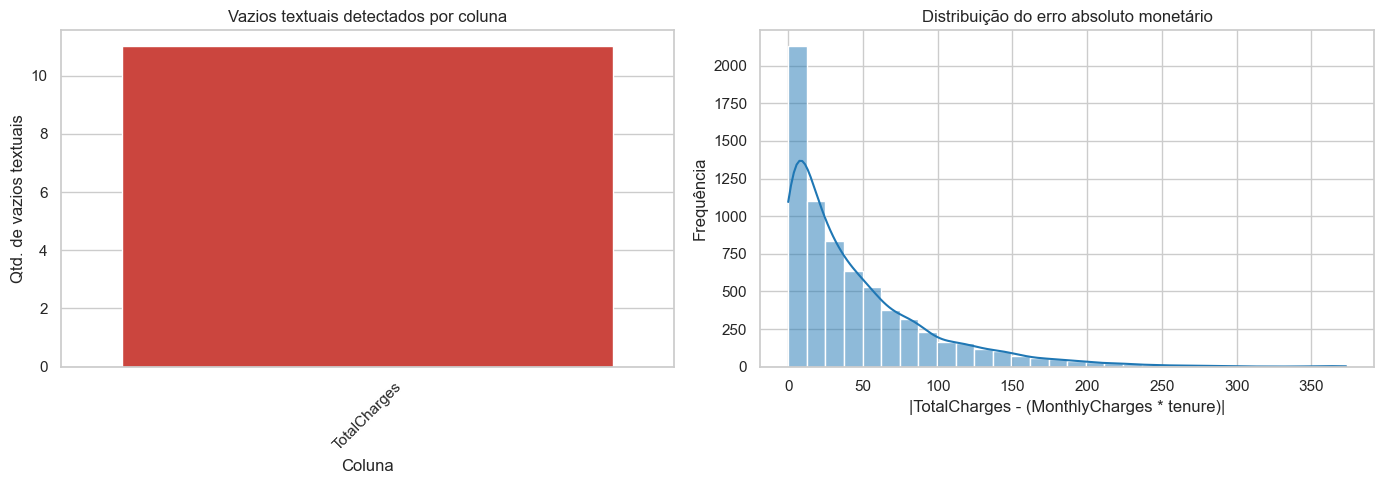

In [24]:
# Código da Questão 2
def data_quality_audit(df: pd.DataFrame, target: str, rare_threshold: float = 0.01) -> dict:
    audit = {}
    audit_df = df.copy()

    # 1) Ausências explícitas e textuais
    missing_abs = audit_df.isna().sum().rename('ausentes_abs')
    missing_pct = (audit_df.isna().mean() * 100).round(2).rename('ausentes_pct')

    text_empty_records = []
    object_cols = audit_df.select_dtypes(include=['object']).columns.tolist()
    for column in object_cols:
        text_series = audit_df[column].astype(str)
        empty_count = int(text_series.str.strip().eq('').sum())
        if empty_count > 0:
            text_empty_records.append({
                'coluna': column,
                'vazios_textuais': empty_count,
                'pct_vazios_textuais': round((empty_count / len(audit_df)) * 100, 2)
            })

    text_empty_df = pd.DataFrame(text_empty_records).sort_values(
        by='vazios_textuais', ascending=False
    ) if text_empty_records else pd.DataFrame(columns=['coluna', 'vazios_textuais', 'pct_vazios_textuais'])

    missing_table = pd.concat([missing_abs, missing_pct], axis=1).reset_index()
    missing_table.columns = ['coluna', 'ausentes_abs', 'ausentes_pct']
    missing_table = missing_table.sort_values(by=['ausentes_abs', 'coluna'], ascending=[False, True])
    audit['missing_table'] = missing_table
    audit['text_empty_table'] = text_empty_df

    # 2) Tipagem inadequada (numérica armazenada como texto)
    type_issue_records = []
    for column in object_cols:
        series = audit_df[column]
        stripped = series.astype(str).str.strip()
        numeric_try = pd.to_numeric(stripped, errors='coerce')

        non_empty = stripped.ne('').sum()
        convertible = numeric_try.notna().sum()
        conversion_ratio = (convertible / non_empty) if non_empty > 0 else 0.0

        if non_empty > 0 and conversion_ratio >= 0.8:
            type_issue_records.append({
                'coluna': column,
                'tipo_detectado': str(series.dtype),
                'sugestao_tipo': 'numérico',
                'taxa_conversao_numerica': round(conversion_ratio * 100, 2)
            })

    type_issues_df = pd.DataFrame(type_issue_records).sort_values(
        by='taxa_conversao_numerica', ascending=False
    ) if type_issue_records else pd.DataFrame(columns=['coluna', 'tipo_detectado', 'sugestao_tipo', 'taxa_conversao_numerica'])
    audit['type_issues'] = type_issues_df

    # 3) Colunas com perfil de identificador (alta cardinalidade)
    id_like_records = []
    for column in audit_df.columns:
        unique_ratio = audit_df[column].nunique(dropna=False) / len(audit_df)
        if unique_ratio > 0.95:
            id_like_records.append({
                'coluna': column,
                'cardinalidade': int(audit_df[column].nunique(dropna=False)),
                'razao_unicidade_pct': round(unique_ratio * 100, 2)
            })

    id_like_df = pd.DataFrame(id_like_records).sort_values(
        by='razao_unicidade_pct', ascending=False
    ) if id_like_records else pd.DataFrame(columns=['coluna', 'cardinalidade', 'razao_unicidade_pct'])
    audit['id_like_columns'] = id_like_df

    # 4) Conversão auxiliar para validações do cenário Telco
    tenure_num = pd.to_numeric(audit_df['tenure'], errors='coerce')
    monthly_num = pd.to_numeric(audit_df['MonthlyCharges'], errors='coerce')
    total_num = pd.to_numeric(audit_df['TotalCharges'].astype(str).str.strip(), errors='coerce')

    numeric_df = pd.DataFrame({
        'tenure': tenure_num,
        'MonthlyCharges': monthly_num,
        'TotalCharges': total_num
    })

    # 5) Valores implausíveis
    implausible_records = []
    rules = {
        'tenure': ('faixa_esperada_0_72', lambda s: (s < 0) | (s > 72)),
        'MonthlyCharges': ('deve_ser_maior_ou_igual_a_0', lambda s: s < 0),
        'TotalCharges': ('deve_ser_maior_ou_igual_a_0', lambda s: s < 0),
    }

    for column, (rule_name, rule_fn) in rules.items():
        series = numeric_df[column]
        invalid_mask = rule_fn(series) & series.notna()
        invalid_count = int(invalid_mask.sum())
        if invalid_count > 0:
            implausible_records.append({
                'coluna': column,
                'regra': rule_name,
                'qtd_registros': invalid_count,
                'pct_registros': round((invalid_count / len(audit_df)) * 100, 4)
            })

    # Regra cruzada: tenure = 0 com TotalCharges > 0 pode indicar inconsistência
    cross_mask = (numeric_df['tenure'] == 0) & (numeric_df['TotalCharges'] > 0)
    cross_count = int(cross_mask.sum())
    if cross_count > 0:
        implausible_records.append({
            'coluna': 'tenure_TotalCharges',
            'regra': 'tenure_zero_deveria_ter_total_zero',
            'qtd_registros': cross_count,
            'pct_registros': round((cross_count / len(audit_df)) * 100, 4)
        })

    implausible_df = pd.DataFrame(implausible_records).sort_values(
        by='qtd_registros', ascending=False
    ) if implausible_records else pd.DataFrame(columns=['coluna', 'regra', 'qtd_registros', 'pct_registros'])
    audit['implausible_values'] = implausible_df

    # 6) Categorias raras (exclui alvo, IDs e colunas com perfil numérico)
    numeric_like_cols = set(type_issues_df['coluna'].tolist())
    id_like_cols = set(id_like_df['coluna'].tolist())
    cat_cols = [c for c in object_cols if c != target and c not in numeric_like_cols and c not in id_like_cols]

    rare_records = []
    for column in cat_cols:
        freq = audit_df[column].astype(str).str.strip().value_counts(dropna=False, normalize=True)
        rare_freq = freq[freq < rare_threshold]
        if len(rare_freq) > 0:
            rare_records.append({
                'coluna': column,
                'qtd_categorias_raras': int(len(rare_freq)),
                'pct_categorias_raras': round((len(rare_freq) / len(freq)) * 100, 2),
                'menor_frequencia_pct': round(float(rare_freq.min() * 100), 4),
                'maior_frequencia_rara_pct': round(float(rare_freq.max() * 100), 4)
            })

    rare_categories_df = pd.DataFrame(rare_records).sort_values(
        by='qtd_categorias_raras', ascending=False
    ) if rare_records else pd.DataFrame(columns=[
        'coluna', 'qtd_categorias_raras', 'pct_categorias_raras',
        'menor_frequencia_pct', 'maior_frequencia_rara_pct'
    ])
    audit['rare_categories'] = rare_categories_df

    # 7) Outliers por IQR
    outlier_records = []
    for column in numeric_df.columns:
        series = numeric_df[column].dropna()
        if series.empty:
            continue

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_mask = (numeric_df[column] < lower) | (numeric_df[column] > upper)
        outlier_count = int(outlier_mask.sum())

        outlier_records.append({
            'coluna': column,
            'q1': round(float(q1), 4),
            'q3': round(float(q3), 4),
            'limite_inferior': round(float(lower), 4),
            'limite_superior': round(float(upper), 4),
            'outliers_abs': outlier_count,
            'outliers_pct': round((outlier_count / len(audit_df)) * 100, 2)
        })

    outliers_df = pd.DataFrame(outlier_records).sort_values(by='outliers_abs', ascending=False)
    audit['outliers_iqr'] = outliers_df

    # 8) Compatibilidade monetária: TotalCharges ~ MonthlyCharges * tenure
    monetary_df = pd.DataFrame({
        'tenure': numeric_df['tenure'],
        'MonthlyCharges': numeric_df['MonthlyCharges'],
        'TotalCharges': numeric_df['TotalCharges']
    }).dropna()

    monetary_df = monetary_df[monetary_df['tenure'] > 0].copy()
    monetary_df['expected_total'] = monetary_df['MonthlyCharges'] * monetary_df['tenure']
    monetary_df['absolute_error'] = (monetary_df['TotalCharges'] - monetary_df['expected_total']).abs()

    if not monetary_df.empty:
        error_q1 = monetary_df['absolute_error'].quantile(0.25)
        error_q3 = monetary_df['absolute_error'].quantile(0.75)
        error_iqr = error_q3 - error_q1
        error_upper = error_q3 + 1.5 * error_iqr
        monetary_df['monetary_suspect'] = monetary_df['absolute_error'] > error_upper
        suspect_count = int(monetary_df['monetary_suspect'].sum())
    else:
        error_upper = np.nan
        suspect_count = 0

    audit['monetary_check'] = {
        'registros_avaliados': int(len(monetary_df)),
        'limite_erro_absoluto_iqr': round(float(error_upper), 4) if pd.notna(error_upper) else None,
        'suspeitos_abs': suspect_count,
        'suspeitos_pct': round((suspect_count / len(df)) * 100, 2),
        'mediana_erro_absoluto': round(float(monetary_df['absolute_error'].median()), 4) if not monetary_df.empty else None
    }
    audit['monetary_df'] = monetary_df

    # 9) Padrão suspeito de preenchimento: TotalCharges ausente com tenure=0
    total_missing_mask = audit_df['TotalCharges'].astype(str).str.strip().eq('')
    total_missing_and_tenure_zero = int((total_missing_mask & (tenure_num == 0)).sum())
    total_missing = int(total_missing_mask.sum())

    audit['fill_pattern'] = {
        'totalcharges_vazios_abs': total_missing,
        'totalcharges_vazios_com_tenure_zero_abs': total_missing_and_tenure_zero,
        'totalcharges_vazios_com_tenure_zero_pct': round(
            (total_missing_and_tenure_zero / total_missing) * 100, 2
        ) if total_missing > 0 else 0.0
    }

    # 10) Resumo da auditoria
    audit['summary'] = {
        'tipagem_inadequada_cols': int(len(type_issues_df)),
        'colunas_com_ausencia_explicita': int((missing_table['ausentes_abs'] > 0).sum()),
        'colunas_com_vazio_textual': int(len(text_empty_df)),
        'colunas_id_like': int(len(id_like_df)),
        'regras_implausiveis_violadas': int(len(implausible_df)),
        'colunas_com_categorias_raras': int(len(rare_categories_df)),
        'colunas_numericas_com_outliers': int((outliers_df['outliers_abs'] > 0).sum()),
        'suspeitos_monetarios_abs': int(audit['monetary_check']['suspeitos_abs'])
    }

    return audit


q2_results = data_quality_audit(df, target='Churn', rare_threshold=0.01)

print('Resumo da auditoria de qualidade:')
for key, value in q2_results['summary'].items():
    print(f'- {key}: {value}')

print('\nTabela de ausências (top 10):')
display(q2_results['missing_table'].head(10))

print('Vazios textuais detectados:')
if q2_results['text_empty_table'].empty:
    print('Nenhum vazio textual detectado.')
else:
    display(q2_results['text_empty_table'])

print('\nPossíveis problemas de tipagem:')
if q2_results['type_issues'].empty:
    print('Nenhuma coluna com forte indício de tipagem inadequada.')
else:
    display(q2_results['type_issues'])

print('\nColunas com perfil de identificador (alta cardinalidade):')
if q2_results['id_like_columns'].empty:
    print('Nenhuma coluna com perfil claro de identificador.')
else:
    display(q2_results['id_like_columns'])

print('\nValores implausíveis:')
if q2_results['implausible_values'].empty:
    print('Nenhum valor implausível encontrado com as regras definidas.')
else:
    display(q2_results['implausible_values'])

print('\nCategorias raras (frequência < 1%):')
if q2_results['rare_categories'].empty:
    print('Nenhuma coluna de atributos categóricos com categorias raras abaixo do limiar.')
else:
    display(q2_results['rare_categories'])

print('\nOutliers por IQR:')
display(q2_results['outliers_iqr'])

print('\nChecagem monetária (TotalCharges vs MonthlyCharges * tenure):')
for key, value in q2_results['monetary_check'].items():
    print(f'- {key}: {value}')

print('\nPadrão de preenchimento suspeito (TotalCharges):')
for key, value in q2_results['fill_pattern'].items():
    print(f'- {key}: {value}')

# Visualizações objetivas para sustentar decisões
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

text_empty_plot_df = q2_results['text_empty_table'].copy()
if text_empty_plot_df.empty:
    text_empty_plot_df = pd.DataFrame({'coluna': ['sem_vazios_textuais'], 'vazios_textuais': [0]})

sns.barplot(data=text_empty_plot_df, x='coluna', y='vazios_textuais', ax=axes[0], palette='Reds_d')
axes[0].set_title('Vazios textuais detectados por coluna')
axes[0].set_xlabel('Coluna')
axes[0].set_ylabel('Qtd. de vazios textuais')
axes[0].tick_params(axis='x', rotation=45)

monetary_plot_df = q2_results['monetary_df'][['absolute_error']].copy()
if monetary_plot_df.empty:
    monetary_plot_df = pd.DataFrame({'absolute_error': [0]})

sns.histplot(data=monetary_plot_df, x='absolute_error', bins=30, kde=True, ax=axes[1], color='#1f77b4')
axes[1].set_title('Distribuição do erro absoluto monetário')
axes[1].set_xlabel('|TotalCharges - (MonthlyCharges * tenure)|')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

### Conclusão da Questão 2
A auditoria confirmou que o principal problema de qualidade da base está concentrado em `TotalCharges`, com 11 vazios textuais (0,16% da base) e forte evidência de tipagem inadequada (coluna textual com 100% de conversão para numérico, exceto vazios). Também foi identificada a coluna `customerID` como variável com perfil de identificador (alta cardinalidade), o que reforça que ela não agrega poder preditivo direto para o problema de churn. Pelas regras de domínio adotadas, não surgiram valores implausíveis evidentes nem outliers pelo critério IQR nas variáveis numéricas principais. Em contrapartida, a checagem monetária `TotalCharges` versus `MonthlyCharges * tenure` encontrou registros com erro absoluto elevado, sinalizando padrões que merecem tratamento criterioso na limpeza. Além disso, todos os vazios de `TotalCharges` ocorreram em clientes com `tenure = 0`, indicando um padrão de preenchimento consistente com clientes recém-entrantes. Esses achados orientam a Questão 3 para: corrigir tipagem, tratar ausências de forma reproduzível e definir estratégia robusta para valores monetários discrepantes.

## Questão 3 – Limpeza dos dados

**Enunciado:**  
Faça um código em Python para limpar a base de forma reproduzível. Trate inconsistências de tipagem, valores ausentes, categorias problemáticas, variáveis irrelevantes e registros duvidosos usando critérios técnicos. Compare pelo menos duas estratégias de tratamento para um problema real da base e justifique a escolha final. Mostre também o impacto quantitativo de cada etapa da limpeza.

### Raciocínio
Escreva aqui a estratégia adotada para responder à questão, explicando de forma objetiva a lógica da análise.

### Desenvolvimento
Implemente abaixo o código da questão.

In [25]:
# Código da Questão 3

### Conclusão da Questão 3
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 4 – Análise exploratória

**Enunciado:**  
Faça um código em Python para desenvolver uma análise exploratória orientada ao problema central da base escolhida. Gere tabelas e visualizações que revelem padrões relevantes entre a variável principal e os demais atributos. Se o cenário envolver classificação, compare os grupos da variável-alvo. Se envolver regressão, investigue relação entre o alvo e as variáveis explicativas. Se envolver segmentação, explore possíveis estruturas de agrupamento. Apresente uma leitura analítica dos resultados obtidos.

### Raciocínio
Escreva aqui a estratégia adotada para responder à questão, explicando de forma objetiva a lógica da análise.

### Desenvolvimento
Implemente abaixo o código da questão.

In [26]:
# Código da Questão 4

### Conclusão da Questão 4
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 5 – Associação entre variáveis

**Enunciado:**  
Faça um código em Python para medir a associação entre as variáveis explicativas e a variável principal da análise. Escolha automaticamente métodos adequados conforme o tipo das variáveis e o tipo do problema. Ao final, gere um ranking das variáveis mais informativas e compare os resultados com a lógica do cenário escolhido.

### Raciocínio
Escreva aqui a estratégia adotada para responder à questão, explicando de forma objetiva a lógica da análise.

### Desenvolvimento
Implemente abaixo o código da questão.

In [27]:
# Código da Questão 5

### Conclusão da Questão 5
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 6 – Engenharia de atributos

**Enunciado:**  
Faça um código em Python para criar pelo menos cinco novos atributos a partir da base original. Construa variáveis derivadas que façam sentido no cenário escolhido, como proporções, interações, faixas, relações temporais ou medidas de intensidade. Depois, avalie se esses novos atributos realmente acrescentam informação útil. Organize essa etapa em uma função reutilizável.

### Raciocínio
Escreva aqui a estratégia adotada para responder à questão, explicando de forma objetiva a lógica da análise.

### Desenvolvimento
Implemente abaixo o código da questão.

In [28]:
# Código da Questão 6

### Conclusão da Questão 6
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 7 – Pré-processamento

**Enunciado:**  
Faça um código em Python para montar um pipeline completo de pré-processamento com `Pipeline` e `ColumnTransformer`. Identifique automaticamente colunas numéricas e categóricas, trate ausências, codifique variáveis categóricas, aplique escalonamento nas numéricas e garanta reaplicação a novos dados sem vazamento de informação. Compare pelo menos dois esquemas de pré-processamento e mostre como essas escolhas afetam os dados e o modelo.

### Raciocínio
Escreva aqui a estratégia adotada para responder à questão, explicando de forma objetiva a lógica da análise.

### Desenvolvimento
Implemente abaixo o código da questão.

In [29]:
# Código da Questão 7

### Conclusão da Questão 7
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 8 – Modelagem com KNN

**Enunciado:**  
Faça um código em Python para dividir a base em treino, validação e teste de forma adequada ao problema escolhido. Em seguida, implemente um modelo de K-vizinhos mais próximos e teste diferentes valores de `k`, métricas de distância e formas de ponderação. Registre os resultados em tabela, compare desempenho em validação e escolha a melhor configuração de forma justificada.

### Raciocínio
Escreva aqui a estratégia adotada para responder à questão, explicando de forma objetiva a lógica da análise.

### Desenvolvimento
Implemente abaixo o código da questão.

In [30]:
# Código da Questão 8

### Conclusão da Questão 8
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 9 – Comparação de modelos

**Enunciado:**  
Faça um código em Python para avaliar o KNN em diferentes cenários de preparação dos dados, como uso ou não de padronização, presença ou ausência de atributos derivados, uso de todas as variáveis ou de um subconjunto selecionado, e tratamento do desbalanceamento quando fizer sentido. Depois, implemente um segundo modelo supervisionado e compare com o melhor KNN em métricas, tempo de execução e perfil dos erros. Conclua se o KNN é ou não uma boa escolha para a base utilizada.

### Raciocínio
Escreva aqui a estratégia adotada para responder à questão, explicando de forma objetiva a lógica da análise.

### Desenvolvimento
Implemente abaixo o código da questão.

In [31]:
# Código da Questão 9

### Conclusão da Questão 9
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 10 – Consolidação da solução

**Enunciado:**  
Faça um código em Python para consolidar toda a solução em um fluxo reutilizável. Implemente uma função que receba um novo caso em formato de dicionário ou `DataFrame` de uma linha, aplique o pipeline construído e retorne a previsão final de forma interpretável. Depois, gere um relatório resumido com a base escolhida, os principais problemas encontrados, os atributos mais relevantes, a melhor configuração do modelo, as métricas finais e uma recomendação executiva. Finalize com uma avaliação crítica sobre a maturidade da solução para uso prático.

### Raciocínio
Escreva aqui a estratégia adotada para responder à questão, explicando de forma objetiva a lógica da análise.

### Desenvolvimento
Implemente abaixo o código da questão.

In [32]:
# Código da Questão 10

### Conclusão da Questão 10
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Conclusão Final

Apresente uma síntese geral do trabalho, destacando:

- principais problemas encontrados na base;
- principais decisões metodológicas;
- melhor configuração de modelo obtida;
- limitações da análise;
- avaliação final da adequação da solução ao cenário escolhido.

**Bom trabalho!**